# Digital Twin Tilt

Use the digital twin to acquire an image, place the beam, collect EDS, and test a stage tilt or stage movement workflow.

## Start the digital twin servers

Open a terminal from the repository root and run:

```bash
uv run startup_scripts/run_servers.py --microscope dt
```



### Imports


In [1]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl


### Ping servers


In [2]:
DB_HOST = '127.0.0.1'
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())


asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Set Tiled Client


In [ ]:
config = json.loads(data.get_config())
config

{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

In [ ]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: []


### Acquire a simulated HAADF image


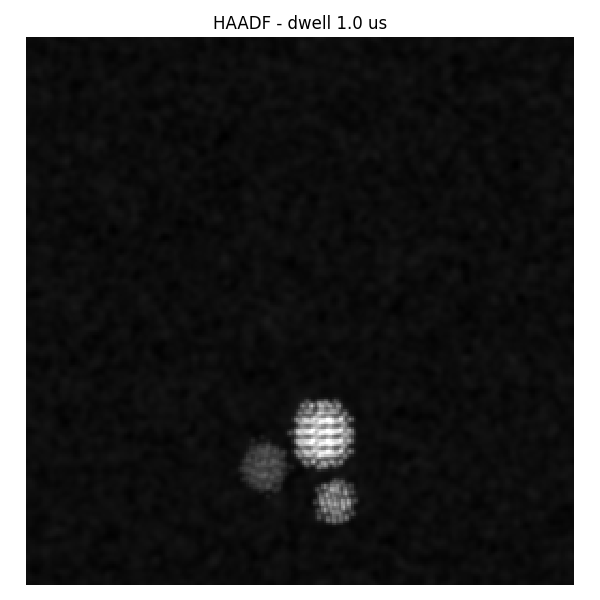

In [4]:
scan.dwell_time = 1e-6
scan.imsize = 256
scan.scan_region = [0, 0, 1, 1]

data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Place the beam


In [5]:
microscope.place_beam([0.36, 0.5])

### Query the beam position


In [6]:
beam_pos = microscope.beam_pos

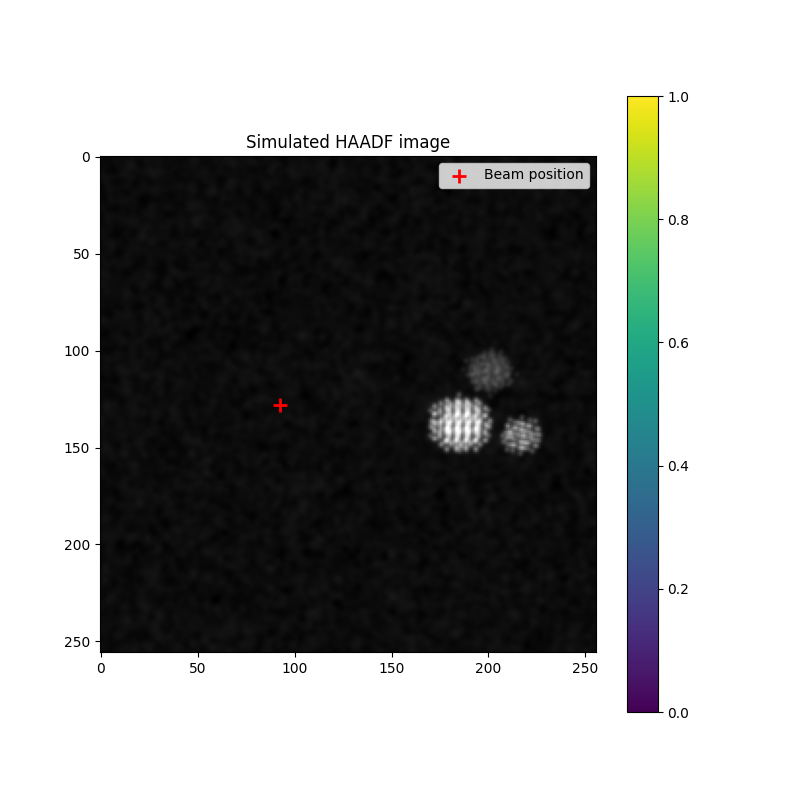

In [7]:
# Read beam position and scale from fractional [0,1] to pixel coordinates
beam_pos = microscope.beam_pos                  # returns [x, y] in [0.0, 1.0]
h, w = image.shape
beam_x_px = beam_pos[0] * w                   # fractional → pixel
beam_y_px = beam_pos[1] * h

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')

# Overlay beam position
plt.scatter(beam_x_px, beam_y_px, 
            color='red', s=100, marker='+',
            linewidths=2, label="Beam position")

plt.title(f"Simulated {metadata['detector']} image")
plt.legend(loc='upper right')
plt.colorbar()
plt.show()

### Acquire a simulated EDS spectrum


In [8]:
key = microscope.acquire_spectrum("eds")
node = client[key]["spectrum"]
spectrum = np.squeeze(np.asarray(node.read()))
metadata = dict(node.metadata)

print("Tiled key     :", key)
print("Metadata      :", metadata)
print("Spectrum shape:", spectrum.shape)
spectrum


Tiled key     : spectrum_eds_20260529T130728685165.h5
Metadata      : {'acquisition_type': 'spectrum', 'detector': 'eds'}
Spectrum shape: (3,)


array([0.0173419 , 0.01080034, 0.01688171])

### Read and move the stage


In [9]:
# get the stage
starting_position = microscope.get_stage()
print('Stage position:', starting_position)

Stage position: [-5.e-09  0.e+00  0.e+00  3.e+01  0.e+00]


In [15]:
# move the stage
move_by = 1e-9 
new_position = starting_position + np.array([move_by, 0, 0, 1, 0])
microscope.move_stage(new_position)

### Acquire an image after movement


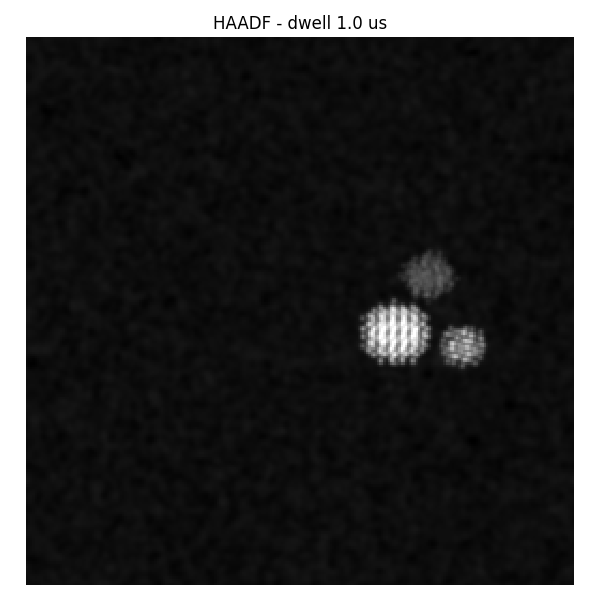

In [16]:
scan.dwell_time = 1e-6
scan.imsize = 256
scan.scan_region = [0, 0, 1, 1]

data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image.T, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()